First we install JAX and Memo, then import the relevant packages.

In [29]:
from memo import memo
import jax
import jax.numpy as np
from enum import IntEnum, auto

Now we define the space of possible roles and actions, and the action likelihoods for each role. As an example, we consider roles that typically role-playing games and team-based shooters:

*   **Fighter**: This role primarily focuses on attacking, with a high likelihood of choosing the Attack action. They have a lower chance of defending or healing.
*   **Tank**: This role is mainly focused on defense, with a high likelihood of choosing the Defend action. They have a lower chance of attacking or healing.
*   **Healer**: This role is primarily focused on supporting others by healing, with a high likelihood of choosing the Heal action. They have a lower chance of attacking or defending.

In [30]:
class Role(IntEnum): Fighter = 0; Tank = 1; Healer = 2
class Action(IntEnum): Attack = 0; Defend = 1; Heal = 2

ROLE_ACTION_PROBS = np.array([
  [0.70, 0.25, 0.05],  # fighter mostly attacks (70% attack, 25% defend, 5% heal)
  [0.25, 0.70, 0.05],  # tank mostly defends (25% attack, 70% defend, 5% heal)
  [0.25, 0.05, 0.70],  # healer mostly heals (25% attack, 5% defend, 70% heal)
])

@jax.jit
def role_policy(role, action):  # role-conditioned action likelihood P(action | role)
    return ROLE_ACTION_PROBS[role, action]

Due to some of memo's limitations, we also need to introduce a helper function that extracts an element from a (3D) array:

In [31]:
@jax.jit
def get_element(array, i0, i1, i2):
    return array[i0, i1, i2]

We'll now define a memo model where a single observer infers the roles of all players in the team based on each of their actions, starting with a prior over roles (specified as an argument).

In [32]:
@memo
def role_inference[r0 : Role, r1 : Role, r2 : Role](role_prior, obs_a0, obs_a1, obs_a2):
    observer: knows(r0, r1, r2) # Push array axis variables into observer's frame
    observer: thinks[
        team: assigned(r0 in Role, r1 in Role, r2 in Role, wpp=get_element(role_prior, r0, r1, r2)), # Assign roles to each player
        team: chooses(a0 in Action, wpp=role_policy(r0, a0)), # Choose player 0's action (a0) according to their role (r0)
        team: chooses(a1 in Action, wpp=role_policy(r1, a1)), # Choose player 1's action (a1) according to their role (r1)
        team: chooses(a2 in Action, wpp=role_policy(r2, a2))  # Choose player 2's action (a2) according to their role (r2)
    ]
    observer: observes_that [team.a0 == obs_a0] # Observe player 0's action
    observer: observes_that [team.a1 == obs_a1] # Observe player 1's action
    observer: observes_that [team.a2 == obs_a2] # Observe player 2's action
    return observer[Pr[r0 == team.r0 and r1 == team.r1 and r2 == team.r2]]

Let's test that role inference works. We assume a uniform prior over all 27 possible role combinations (`role_prior = np.ones((3, 3, 3))`), and observe that the first player attacks, the second player defends, and the third player heals:

In [42]:
# Specify role prior
role_prior = np.ones((3, 3, 3))
# Specify observed actions
actions = [Action.Heal, Action.Defend, Action.Heal]
# Run inference and print results
role_probs = role_inference(role_prior, *actions, print_table=True)

+----------+----------+----------+-------------------------+
| r0: Role | r1: Role | r2: Role | role_inference          |
+----------+----------+----------+-------------------------+
| Fighter  | Fighter  | Fighter  | 0.0009765625            |
| Fighter  | Fighter  | Tank     | 0.0009765625            |
| Fighter  | Fighter  | Healer   | 0.013671874068677425    |
| Fighter  | Tank     | Fighter  | 0.002734375186264515    |
| Fighter  | Tank     | Tank     | 0.002734375186264515    |
| Fighter  | Tank     | Healer   | 0.03828125074505806     |
| Fighter  | Healer   | Fighter  | 0.00019531248835846782  |
| Fighter  | Healer   | Tank     | 0.00019531248835846782  |
| Fighter  | Healer   | Healer   | 0.002734375186264515    |
| Tank     | Fighter  | Fighter  | 0.0009765625            |
| Tank     | Fighter  | Tank     | 0.0009765625            |
| Tank     | Fighter  | Healer   | 0.013671874068677425    |
| Tank     | Tank     | Fighter  | 0.002734375186264515    |
| Tank     | Tank     | 

As one might expect, the most likely inference is that the team is composed of a Fighter, Tank and Healer (in that order). We can manually inspect the probability of this combination below:

In [34]:
# Print the probability of the Fighter, Tank, Healer combination
print(f"Probability of Fighter, Tank, Healer combination: {role_probs[Role.Fighter, Role.Tank, Role.Healer]}")

Probability of Fighter, Tank, Healer combination: 0.03828125074505806


We can also marginalize out some of the axes, so that we get the probability distribution over roles for just one of the players:

In [35]:
def marginalize(probs, keepaxis):
    return np.sum(probs, axis=tuple(i for i in range(probs.ndim) if i != keepaxis))

# Print the distribution over roles for each player
print(f"Distribution over roles for player 0: {marginalize(role_probs, 0)}")
print(f"Distribution over roles for player 1: {marginalize(role_probs, 1)}")
print(f"Distribution over roles for player 2: {marginalize(role_probs, 2)}")

Distribution over roles for player 0: [0.0625     0.0625     0.87499994]
Distribution over roles for player 1: [0.24999997 0.7        0.05      ]
Distribution over roles for player 2: [0.06249999 0.06249999 0.87499994]


Suppose the observer knows that there is only one player assigned to each role in the whole team. We can encode this assumption by changing the prior so that it assigns positive probability to only role combinations where all roles differ:

In [36]:
# Create a constrained prior that ensures role uniqueness
i, j, k = np.indices((3, 3, 3))
mask = (i != j) & (i != k) & (j != k)
constrained_prior = mask.astype(np.float32)
# Run role inference and print results
role_probs = role_inference(constrained_prior, *actions, print_table=True)

+----------+----------+----------+------------------------+
| r0: Role | r1: Role | r2: Role | role_inference         |
+----------+----------+----------+------------------------+
| Fighter  | Fighter  | Fighter  | 0.0                    |
| Fighter  | Fighter  | Tank     | 0.0                    |
| Fighter  | Fighter  | Healer   | 0.0                    |
| Fighter  | Tank     | Fighter  | 0.0                    |
| Fighter  | Tank     | Tank     | 0.0                    |
| Fighter  | Tank     | Healer   | 0.3670412003993988     |
| Fighter  | Healer   | Fighter  | 0.0                    |
| Fighter  | Healer   | Tank     | 0.0018726594280451536  |
| Fighter  | Healer   | Healer   | 0.0                    |
| Tank     | Fighter  | Fighter  | 0.0                    |
| Tank     | Fighter  | Tank     | 0.0                    |
| Tank     | Fighter  | Healer   | 0.13108615577220917    |
| Tank     | Tank     | Fighter  | 0.0                    |
| Tank     | Tank     | Tank     | 0.0  

Since repeated roles are no longer allowed, the Fighter, Tank, Healer combination ends up having a much higher posterior probability.

Now let's model a situation where each player starts off unsure which role it is supposed to play, but where all players gradually converge to a shared role assignment over the course of multiple steps by inferring the role assignment that best explains the actions they've taken so far. At every step, each agent:
1. Samples a role according to its current belief distribution over its own role.
2. Takes an action according to the policy for that role.
3. Updates its belief about the role assignments given the actions taken by all players.

For simplicity, we'll assume that all agents start with a common prior, so that we don't have to perform separate belief updates for each agent (a common prior leads to a common posterior under full observability).

Since memo doesn't readily support sampling or for-loops, we will write this part using regular Python code:

In [37]:
import random

def simulate_role_convergence(n_steps, role_prior):
  role_probs = role_prior
  # Preallocate arrays for histories
  role_history = np.zeros((n_steps, 3), dtype=np.int32)
  action_history = np.zeros((n_steps, 3), dtype=np.int32)
  role_prob_history = np.zeros((n_steps, 3, 3, 3), dtype=np.float32)
  for t in range(n_steps):
    # Sample a role for each agent according to the marginal distribution over their role
    roles = [random.choices([0, 1, 2], weights=marginalize(role_probs, i))[0] for i in range(3)]
    role_history = role_history.at[t].set(np.array(roles)) # Store roles

    # Sample an action for each agent according to the role policy
    actions = [random.choices([0, 1, 2], weights=ROLE_ACTION_PROBS[r, :])[0] for r in roles]
    action_history = action_history.at[t].set(np.array(actions)) # Store actions

    # Update (common) beliefs about role assignments via role inference
    role_probs = role_inference(role_probs, *actions)
    role_prob_history = role_prob_history.at[t].set(role_probs) # Store updated probabilities

  return role_history, action_history, role_prob_history

Now let's simulate role convergence for 10 steps, starting from a uniform prior:

In [38]:
# random.seed(10)
n_steps = 10
role_prior = np.ones((3, 3, 3))
role_history, action_history, role_prob_history = simulate_role_convergence(n_steps, role_prior)

In this run, the sampled roles and actions changed as follows:

In [39]:
print("Simulation History:")
print(f"{'Timestep':<10} | {'Player 1':<15} | {'Player 2':<15} | {'Player 3':<15}")
print("-" * 60)

for t in range(n_steps):
    roles = [Role(r).name for r in role_history[t]]
    actions = [Action(a).name for a in action_history[t]]
    print(f"{f'Step {t+1}':<10} | {roles[0]:<15} | {roles[1]:<15} | {roles[2]:<15}")
    print(f"{'':<10} | {actions[0]:<15} | {actions[1]:<15} | {actions[2]:<15}")

Simulation History:
Timestep   | Player 1        | Player 2        | Player 3       
------------------------------------------------------------
Step 1     | Tank            | Healer          | Fighter        
           | Defend          | Heal            | Attack         
Step 2     | Tank            | Healer          | Fighter        
           | Defend          | Heal            | Attack         
Step 3     | Fighter         | Healer          | Fighter        
           | Attack          | Attack          | Attack         
Step 4     | Tank            | Healer          | Fighter        
           | Defend          | Attack          | Heal           
Step 5     | Tank            | Healer          | Healer         
           | Attack          | Heal            | Defend         
Step 6     | Tank            | Healer          | Fighter        
           | Attack          | Heal            | Defend         
Step 7     | Tank            | Healer          | Fighter        
         

The roles appear to converge after an initial period of instability. We can also plot the inferred distribution over each agent's role over time:

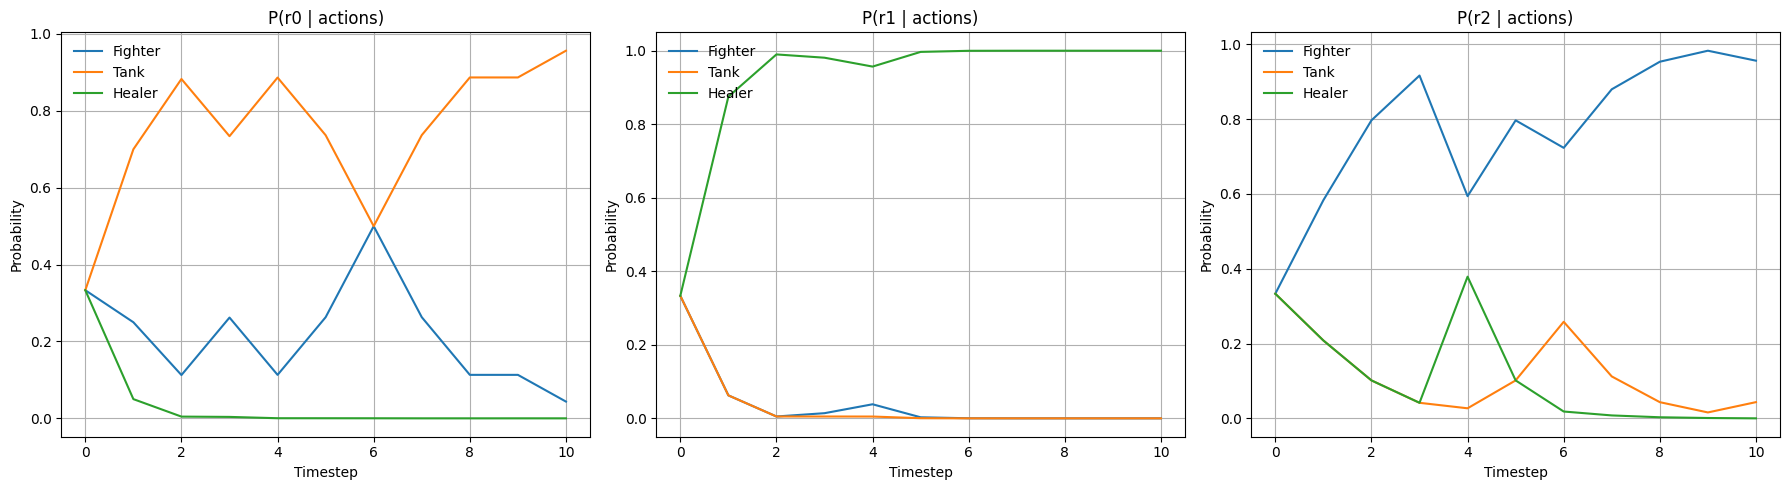

In [40]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplots, one for each player
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3): # Iterate over players
    # Calculate marginal probabilities for the current player at each timestep
    player_role_probs = [marginalize(role_prob_history[t], i) for t in range(n_steps)]
    # Add the initial timestep's probabilities
    player_role_probs.insert(0, marginalize(role_prior / role_prior.sum(), i))
    player_role_probs = np.array(player_role_probs)

    # Plot the evolution of role probabilities for the current player
    for role in Role:
        axes[i].plot(range(n_steps + 1), player_role_probs[:, role], label=role.name)

    axes[i].set_title(f'P(r{i} | actions)')
    axes[i].set_xlabel('Timestep')
    axes[i].set_ylabel('Probability')
    axes[i].legend(frameon=False, loc='upper left')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

This serves as a basic model of decentralized role coordination via iterative updating of each player's beliefs. Many extensions are possible, including:
- **Structured Priors:** Using a prior over role assignments that disallows or downweights repeated roles (as above), then testing if that results in faster role differentiation and convergence.
- **Dynamic Roles / Types:** Instead of assuming that roles never change, allow for an $\epsilon$ probability that agent's role assignments will be resampled from the prior over roles at each step. This should result in more gradual belief updates and less dependence on observations far into the past.
- **Uncommon Beliefs:** Instead of assuming a common prior, different agents could start with different beliefs about the role assignments (e.g. maybe one player is really certain they are a Tank), and experiments could test whether convergence is still possible.
- **Statefulness:** Extending the game with a state space $S$ and a transition function $T(s' | a, s)$, then adjusting the role-based policies to depend on the state (i.e. definining $\pi(a | s, \theta)$ instead of just $\pi(a | r, \theta)$, where $\theta$ is the role).
  - e.g. Maybe each player has a health bar which changes depending on whether they attack, defend or heal, so the state is the health status of each agent.
  - Then the role policies can depend on the state, e.g. the healer will heal with high probability if another agent is hurt, but attack otherwise.
  - To more easily define these conditional policies, using JAX control flow primitives might be helpful: https://docs.jax.dev/en/latest/control-flow.html#structured-control-flow-primitives
  - In addition to dynamic state, each agent could also have static characteristics ("player stats") that could make them more fit or less fit for a particular role, and the role prior could depend on these characteristics (see below on utility-weighted role priors).
- **Adding Utilities / Rewards:** If each agent is given a reward or utility function, then several interesting extensions are possible:
  - **Utility-Weighted Role Priors**: Similar to Bayesian Delegation, agent's might assign higher prior probabilities to role combinations that lead to higher team utility in the long run. The utility of a role combination can be estimated by computing the expected cumulative reward that the team accrues if all members were to follow the policies for those roles for a number of steps into the future. This addition is probably more interesting if you allow for dynamic roles / types, and/or if players have different levels of fitness for each role (e.g. players with higher max health might be better tanks).
  - **Role-Based Constraints instead of Policies**: Instead of directly specifying the policy associated with each role, roles impose constraints on what actions are allowed (e.g. healers are never allowed to defend, fighters are never allowed to heal), and the resulting policy for each role is computed via planning / value iteration to (softly) maximize reward under the constraint.
  - **Role-Based Reward Functions**: Instead of directly specifying the policy for each role (and having a shared reward function for the whole team), each role is associated with a distinct reward function specifying what outcomes the player should care about (e.g. maybe a healer is rewarded for ensuring everyone is at max life, and less for attacking). The resulting policy for each role is then computed via planning to (softly) maximize reward.
